# Exploratory Data Analysis (EDA) on Open-Meteo Dataset

In [1]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from scipy import stats

from src.descriptions import aq_measurements, aq_descriptions
from src.eda import understand_features, assess_features, find_central_tendency
from src.enums import aq_keys, files
from pandas.api.types import is_numeric_dtype

aq = pd.read_csv(files['data/02-28-open-meteo-base.csv'])

## Understand air quality features
Identify what kind of information is in each column, such as measurement and description.

In [2]:
understand_features(aq, aq_measurements, aq_descriptions)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23208 entries, 0 to 23207
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   time                             23208 non-null  object 
 1   us_aqi (USAQI)                   23208 non-null  int64  
 2   us_aqi_pm2_5 (USAQI)             23208 non-null  int64  
 3   us_aqi_pm10 (USAQI)              23208 non-null  int64  
 4   us_aqi_nitrogen_dioxide (USAQI)  23208 non-null  int64  
 5   us_aqi_carbon_monoxide (USAQI)   23208 non-null  int64  
 6   us_aqi_ozone (USAQI)             23208 non-null  int64  
 7   us_aqi_sulphur_dioxide (USAQI)   23208 non-null  int64  
 8   methane (μg/m³)                  11624 non-null  float64
 9   uv_index_clear_sky ()            23208 non-null  float64
 10  uv_index ()                      23208 non-null  float64
 11  dust (μg/m³)                     23208 non-null  int64  
 12  aerosol_optical_de

,Measurement Type,Description
time,interval,Time of the measurement.
us_aqi (USAQI),ordinal,Air Quality Index is the overall standardized ...
us_aqi_pm2_5 (USAQI),ordinal,AQI for PM2.5 particles.
us_aqi_pm10 (USAQI),ordinal,AQI for PM10 particles.
us_aqi_nitrogen_dioxide (USAQI),ordinal,AQI for Nitrogen Dioxide.
us_aqi_carbon_monoxide (USAQI),ordinal,AQI for Carbon Monoxide.
us_aqi_ozone (USAQI),ordinal,AQI for Ozone.
us_aqi_sulphur_dioxide (USAQI),ordinal,AQI for Sulphur Dioxide.
methane (μg/m³),ratio,A potent greenhouse gas that increases ozone l...
uv_index_clear_sky (),ratio,Measurement of the intensity of ultraviolet ra...


## Pre-narrow air quality data features
Based on feature descriptions, identify which features are unnecessary, and remove them to focus on relevant features and avoid wasting time.

In [3]:
# No column will be dropped.
aq_preview = aq.copy()
aq_preview['null_count'] = aq_preview.isnull().sum(axis=1)
aq_preview.sort_values('null_count', ascending=True).head(3).drop('null_count', axis=1)

,time,us_aqi (USAQI),us_aqi_pm2_5 (USAQI),us_aqi_pm10 (USAQI),us_aqi_nitrogen_dioxide (USAQI),us_aqi_carbon_monoxide (USAQI),us_aqi_ozone (USAQI),us_aqi_sulphur_dioxide (USAQI),methane (μg/m³),uv_index_clear_sky (),uv_index (),dust (μg/m³),aerosol_optical_depth (),ozone (μg/m³),sulphur_dioxide (μg/m³),nitrogen_dioxide (μg/m³),carbon_dioxide (ppm),pm2_5 (μg/m³),carbon_monoxide (μg/m³),pm10 (μg/m³)
11603,2024-10-26 11:00,61,61,23,6,5,18,4,1388.0,4.65,4.25,0,0.03,86,7.3,11.7,459.0,6.2,292,9.2
15475,2025-04-05 19:00,53,53,17,13,2,50,3,1454.0,0.00,0.00,3,0.10,67,5.5,25.9,463.0,14.3,335,17.7
15474,2025-04-05 18:00,53,53,16,9,2,50,3,1433.0,0.05,0.05,3,0.10,85,5.1,18.5,458.0,12.7,301,16.2


## Assess air quality features

Document anomalies such as missing and NaN values. This will be referenced when fixing the data.

In [4]:
display(assess_features(aq, aq_measurements))

aq_assessment_no_time = aq.drop(columns = ['time'])
duplicated_rows = aq_assessment_no_time.duplicated().sum()
print("Duplicated Rows: " + str(duplicated_rows))

,Null Count,Null Percentage,Measurement Type,Duplicate Count,Duplicate Percentage
time,0,0.00,interval,0,0.00
us_aqi (USAQI),0,0.00,ordinal,23111,99.58
us_aqi_pm2_5 (USAQI),0,0.00,ordinal,23119,99.62
us_aqi_pm10 (USAQI),0,0.00,ordinal,23178,99.87
us_aqi_nitrogen_dioxide (USAQI),0,0.00,ordinal,23170,99.84
us_aqi_carbon_monoxide (USAQI),0,0.00,ordinal,23197,99.95
us_aqi_ozone (USAQI),0,0.00,ordinal,23101,99.54
us_aqi_sulphur_dioxide (USAQI),0,0.00,ordinal,23196,99.95
methane (μg/m³),11584,49.91,ratio,11101,47.83
uv_index_clear_sky (),0,0.00,ratio,22986,99.04


Duplicated Rows: 0


## Find central tendency of air quality features
Determine if the data is symmetrical. If the data is skewed, a more robust scaling method should be used, like log scaling.

In [5]:
find_central_tendency(aq, aq_measurements)

,Measurement Type,Mean,Median,Skewness,Skew Direction
time,interval,N/A,N/A,N/A,N/A
us_aqi (USAQI),ordinal,40.32,38.0,0.81,Moderately Right Skewed
us_aqi_pm2_5 (USAQI),ordinal,37.09,36.0,0.39,Symmetrical
us_aqi_pm10 (USAQI),ordinal,11.36,11.0,0.67,Moderately Right Skewed
us_aqi_nitrogen_dioxide (USAQI),ordinal,8.2,5.0,1.27,Highly Right Skewed
us_aqi_carbon_monoxide (USAQI),ordinal,2.36,2.0,1.75,Highly Right Skewed
us_aqi_ozone (USAQI),ordinal,25.05,25.0,0.58,Moderately Right Skewed
us_aqi_sulphur_dioxide (USAQI),ordinal,1.52,1.0,1.5,Highly Right Skewed
methane (μg/m³),ratio,1469.48,1445.0,1.52,Highly Right Skewed
uv_index_clear_sky (),ratio,1.43,0.0,1.88,Highly Right Skewed


## Measure variability of air quality features

In [6]:
table_columns = ['Feature', 'q1', 'q3', 'iqr', 'std_dev', 'cv', 'lower_limit', 'upper_limit']
table_rows = []
for key in aq.columns:
    if not is_numeric_dtype(aq[key]):
        continue
    v = aq[key].dropna()
    q1 = np.percentile(v,25)
    q3 = np.percentile(v, 75)
    iqr = stats.iqr(v)
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    std_dev = np.std(v)
    cv = stats.variation(v)
    table_rows.append([
        key,
        q1,
        q3,
        iqr,
        std_dev,
        cv,
        lower_limit,
        upper_limit
    ])
aq_table = pd.DataFrame(data = table_rows, columns=table_columns)
aq_table

,Feature,q1,q3,iqr,std_dev,cv,lower_limit,upper_limit
0,us_aqi (USAQI),31.00,49.00,18.00,12.609684,0.312753,4.000,76.000
1,us_aqi_pm2_5 (USAQI),26.00,48.00,22.00,14.678415,0.395741,-7.000,81.000
2,us_aqi_pm10 (USAQI),8.00,14.00,6.00,4.497116,0.395870,-1.000,23.000
3,us_aqi_nitrogen_dioxide (USAQI),2.00,12.00,10.00,7.549652,0.921147,-13.000,27.000
4,us_aqi_carbon_monoxide (USAQI),2.00,3.00,1.00,1.139675,0.482058,0.500,4.500
5,us_aqi_ozone (USAQI),16.00,33.00,17.00,12.248944,0.488939,-9.500,58.500
6,us_aqi_sulphur_dioxide (USAQI),1.00,2.00,1.00,1.041692,0.683080,-0.500,3.500
7,methane (μg/m³),1403.00,1510.00,107.00,91.098563,0.061994,1242.500,1670.500
8,uv_index_clear_sky (),0.00,1.95,1.95,2.422870,1.696295,-2.925,4.875
9,uv_index (),0.00,1.55,1.55,2.299341,1.782996,-2.325,3.875


## Visualize distribution of air quality features

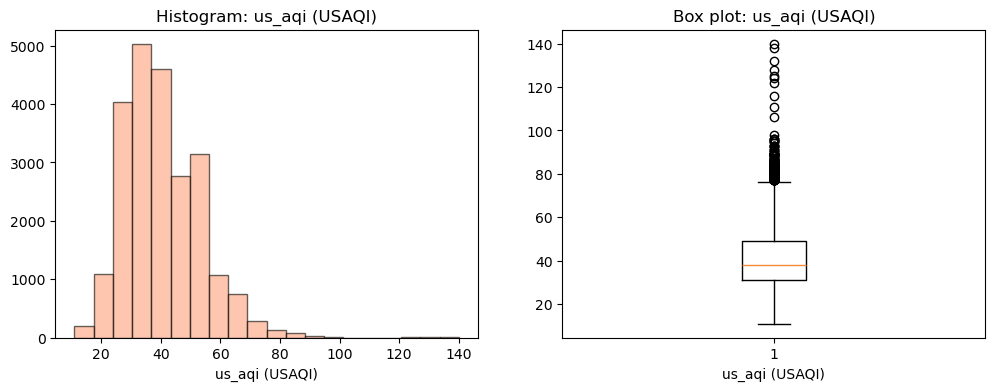

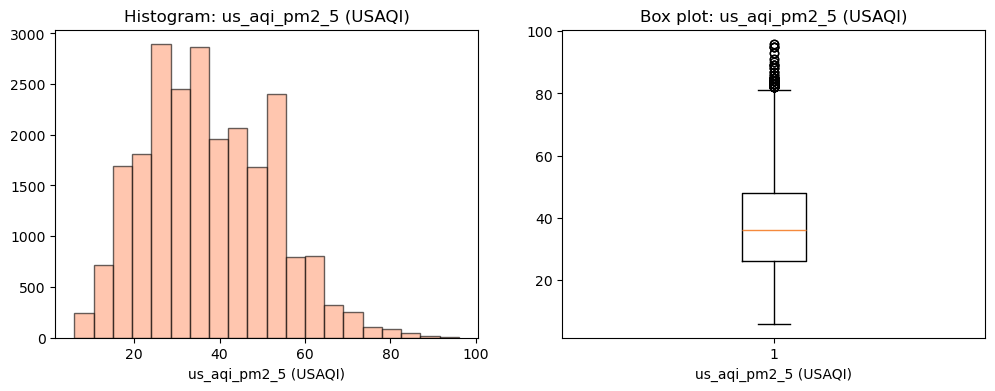

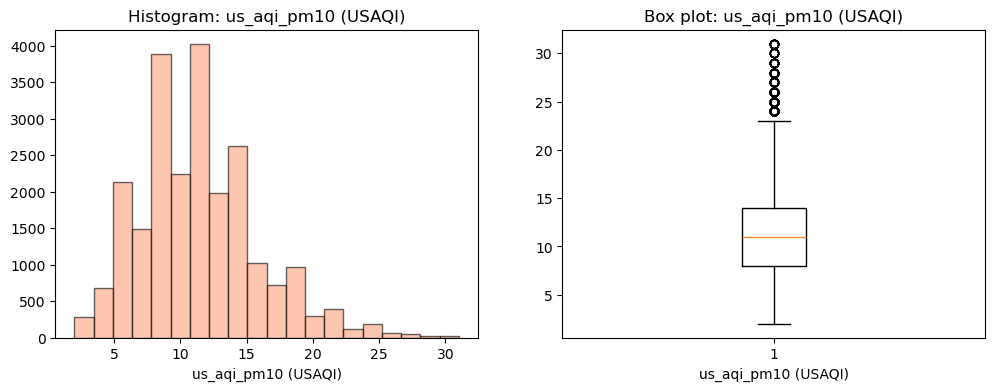

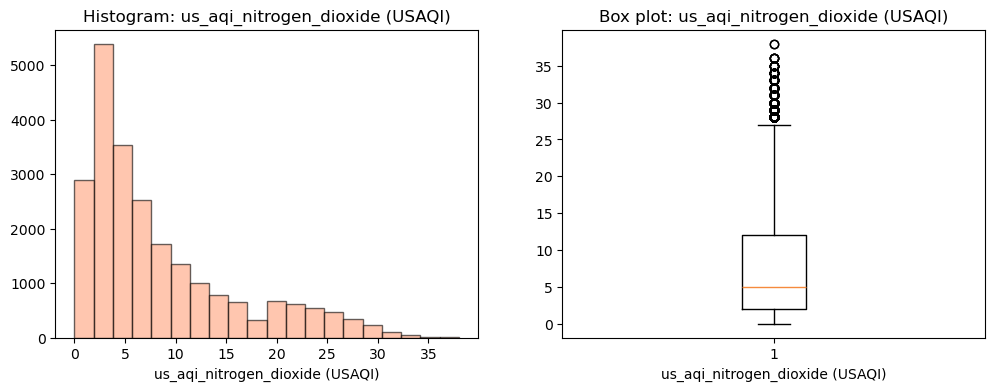

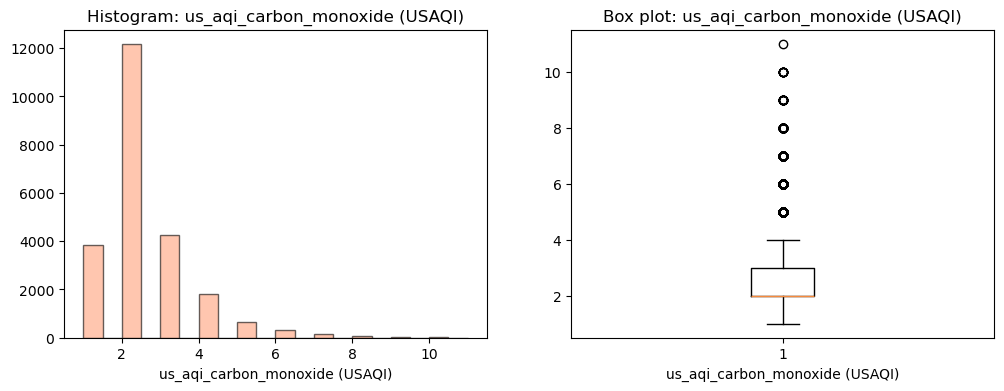

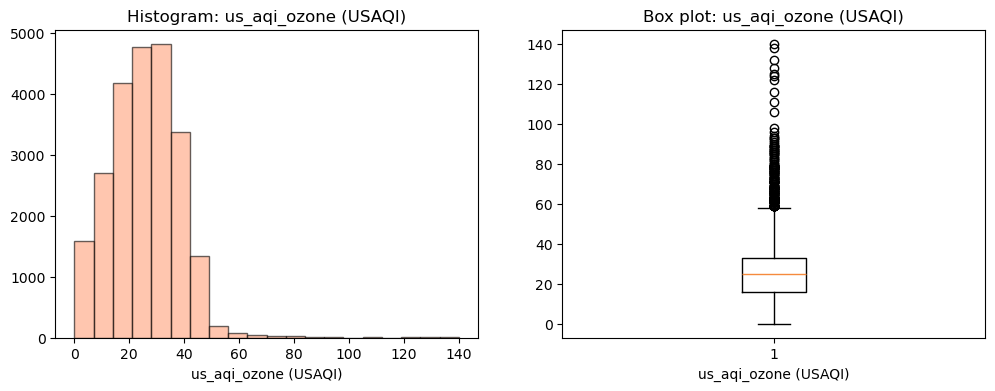

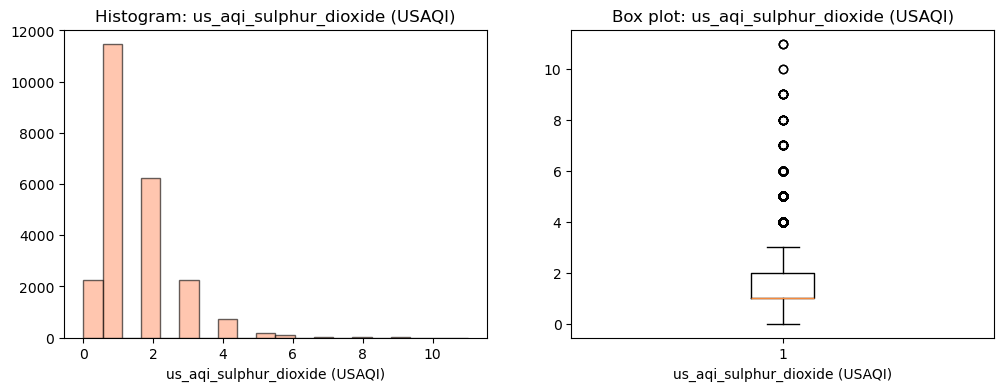

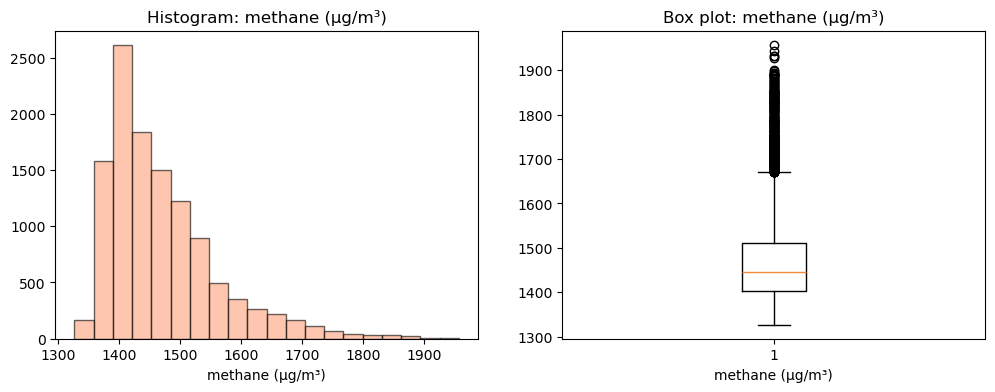

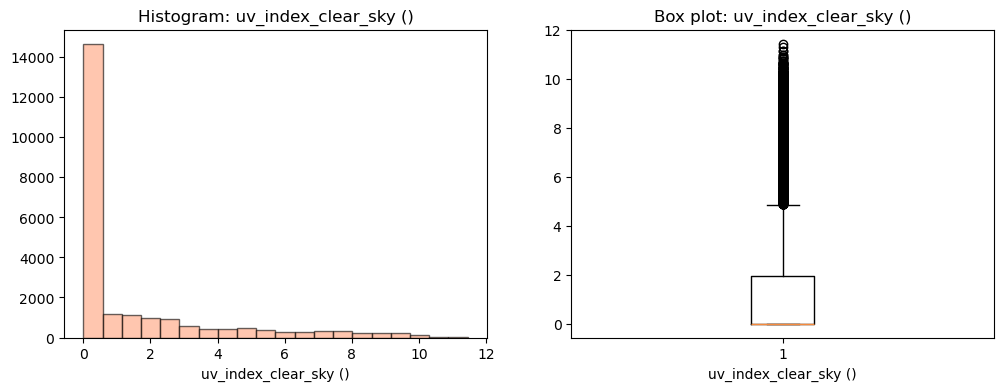

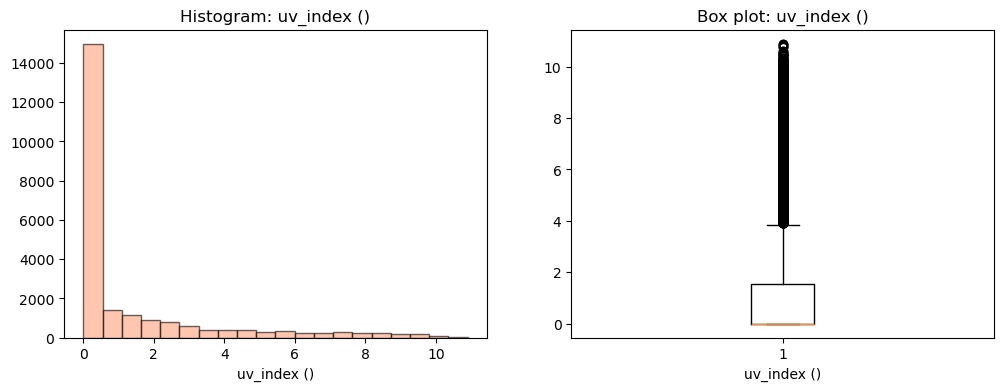

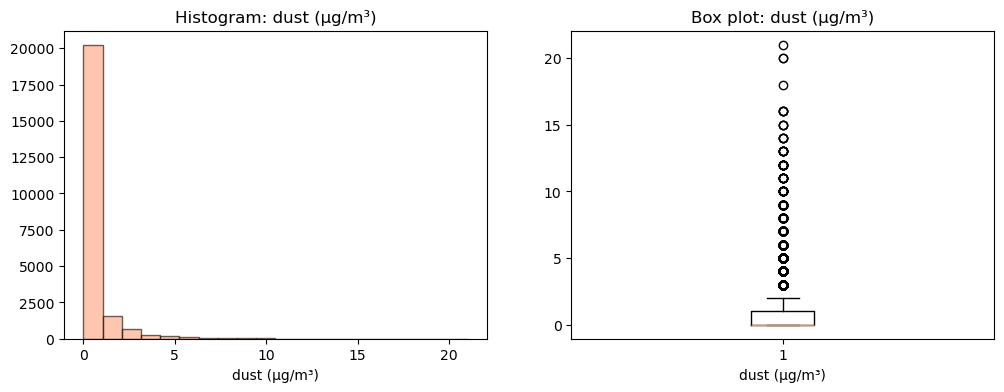

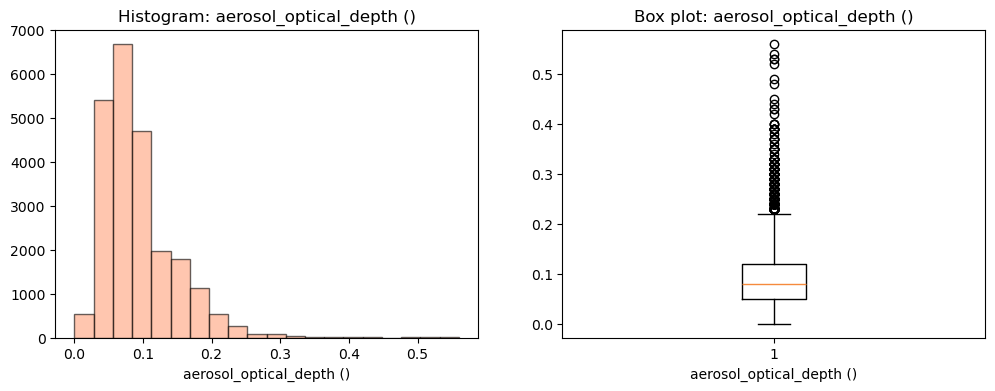

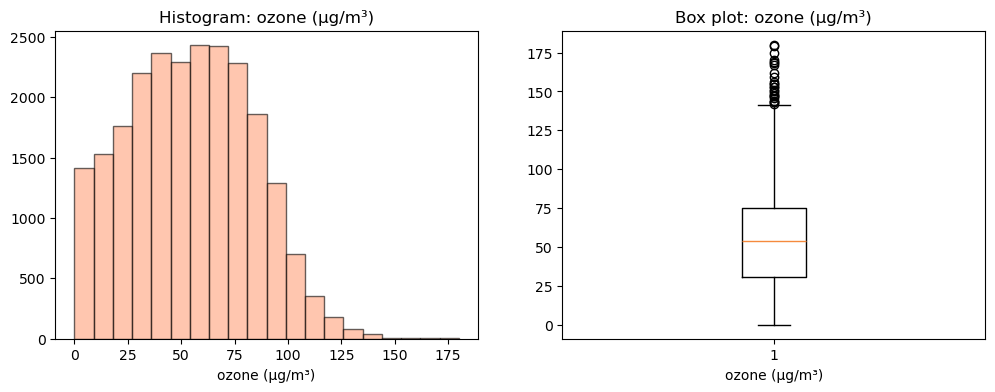

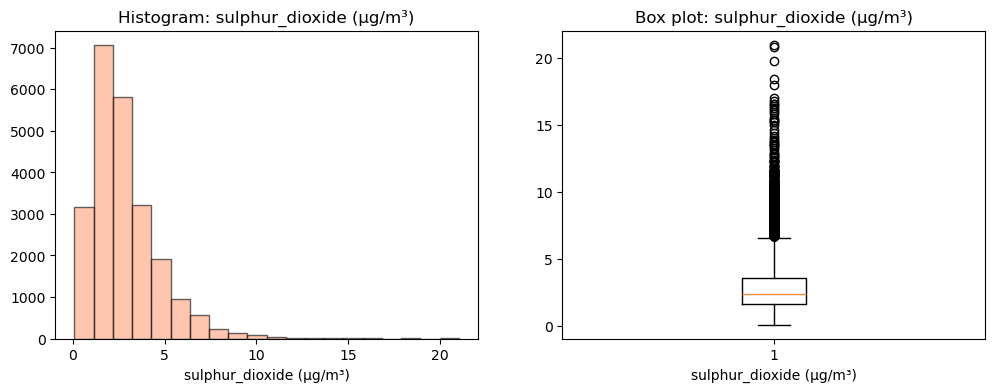

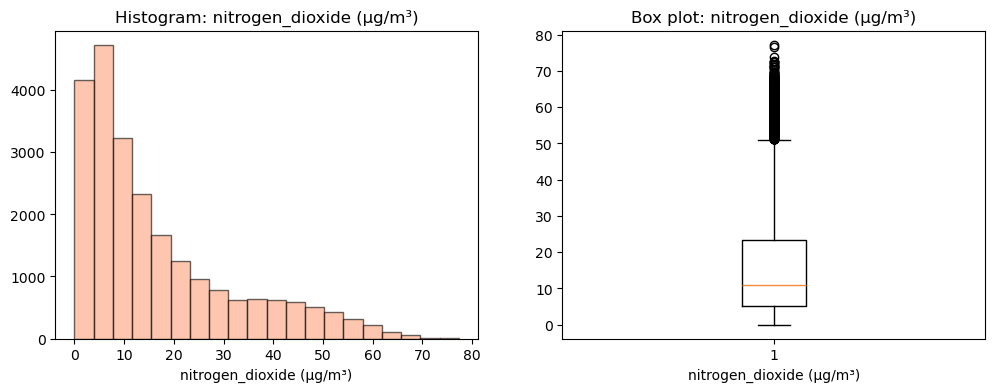

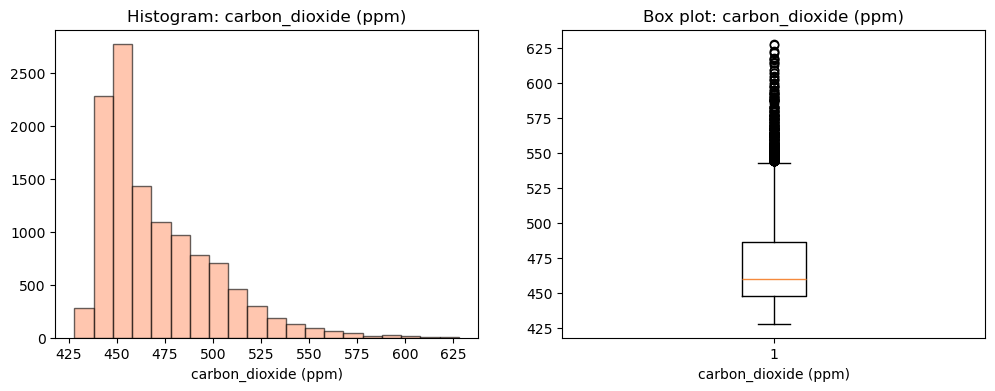

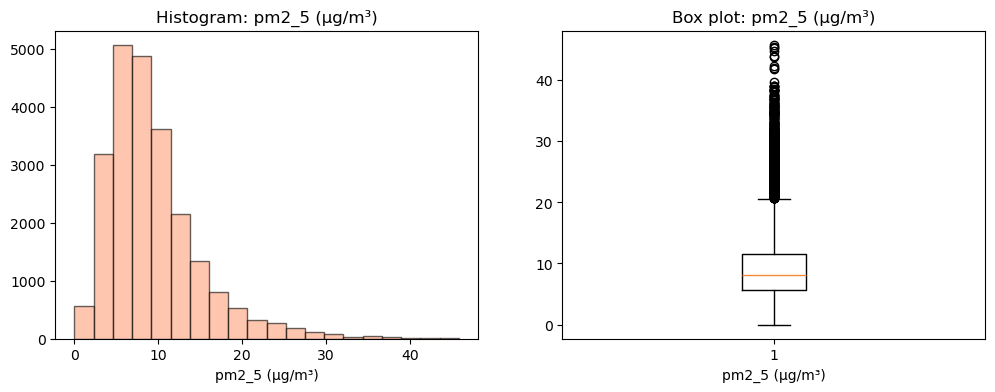

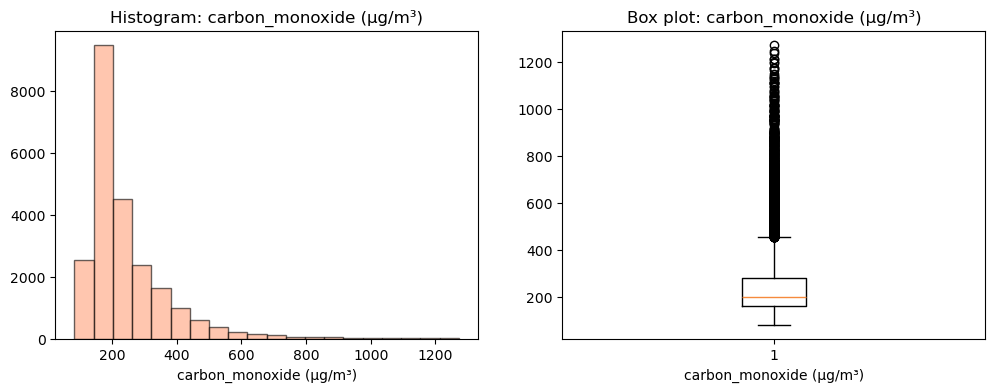

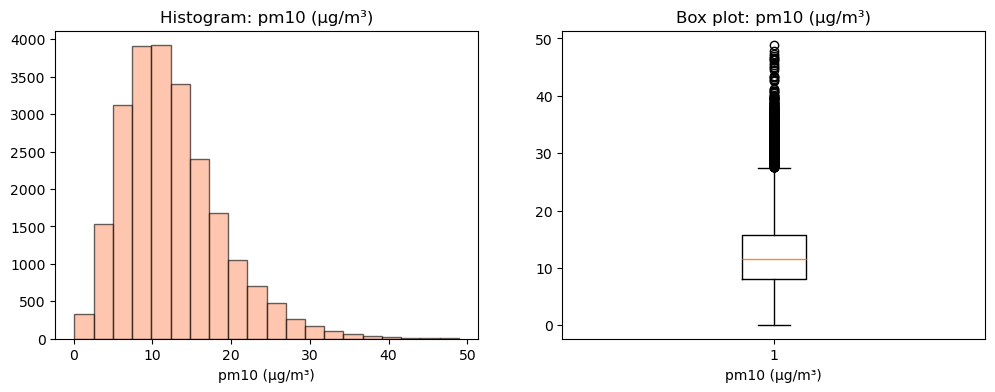

In [7]:
# Histogram guide:https://www.stratascratch.com/blog/how-to-create-a-matplotlib-histogram

for key in aq.columns:
    if not is_numeric_dtype(aq[key]):
        continue
    v = aq[key].dropna()
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.title("Histogram: " + key)
    plt.xlabel(key)
    plt.hist(v, alpha = 0.6, bins=20, color='lightsalmon', edgecolor='black')
    
    plt.subplot(1, 2, 2)
    plt.title("Box plot: " + key)
    plt.xlabel(key)
    plt.boxplot(v)
    plt.show()


## Correlate air quality features

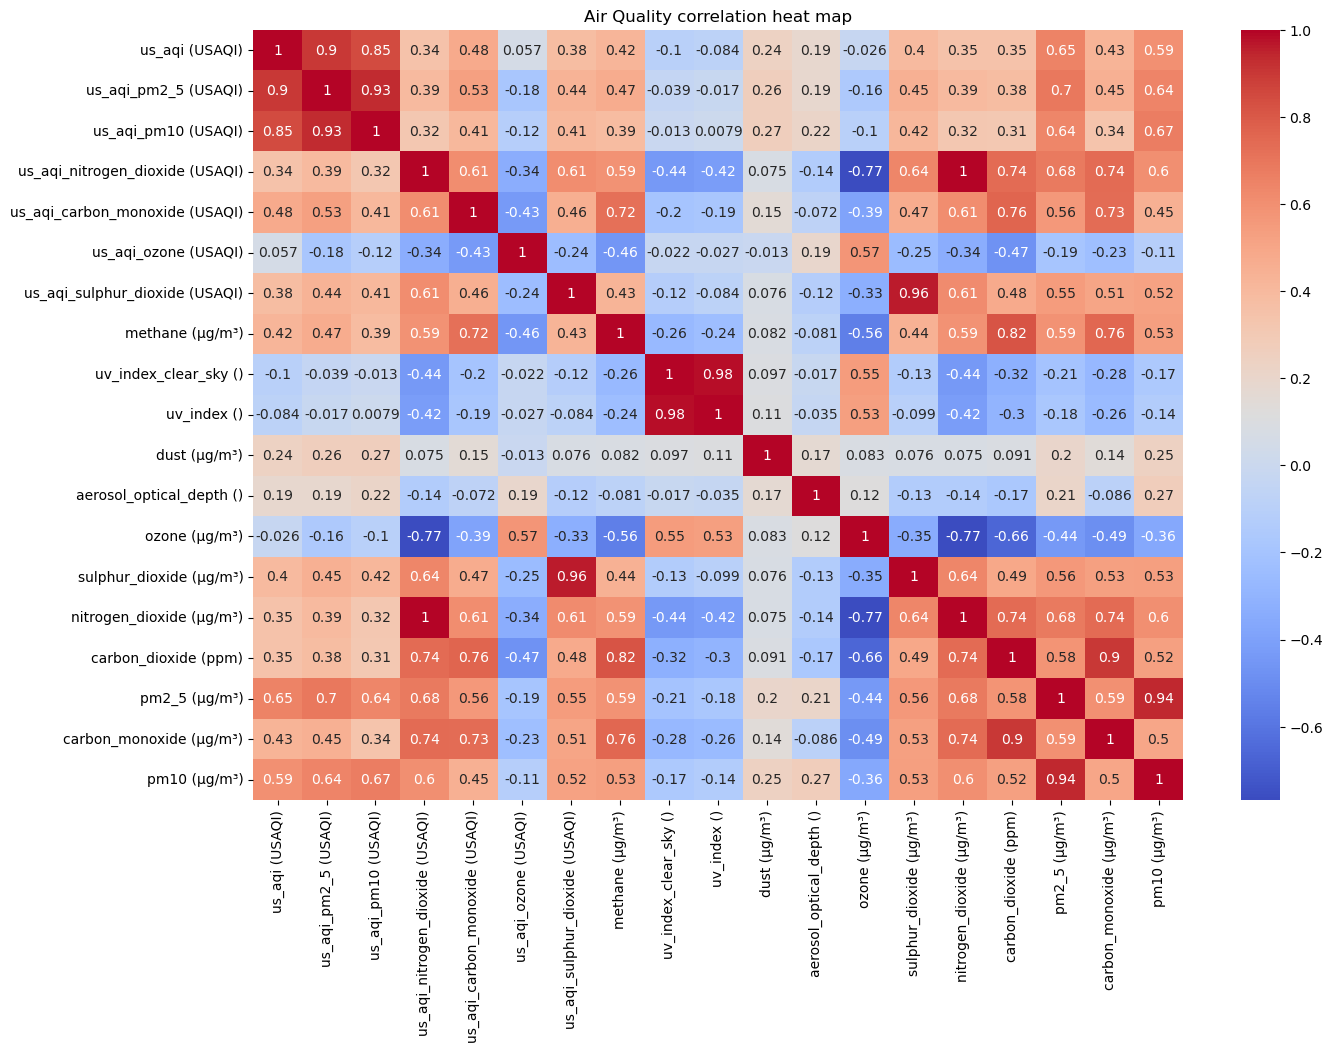

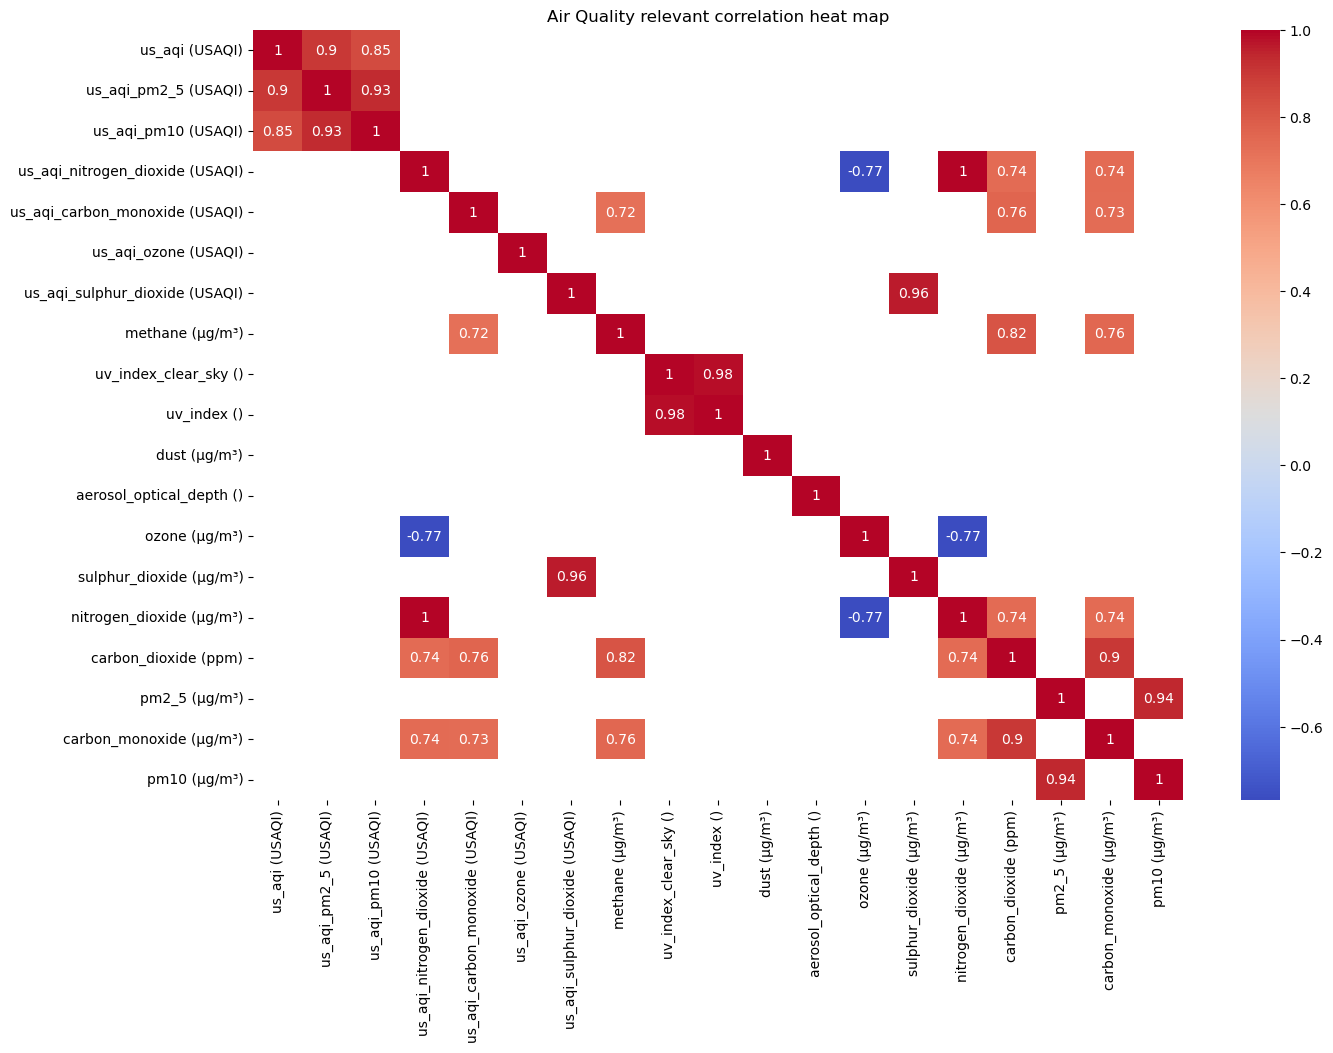

In [8]:
aq_corr = aq.corr(numeric_only=True)
plt.figure(figsize=(15, 10))
plt.title('Air Quality correlation heat map')
sb.heatmap(data= aq_corr , annot=True, cmap= 'coolwarm')
plt.show()

plt.figure(figsize=(15, 10))
plt.title('Air Quality relevant correlation heat map')
sb.heatmap(data= aq_corr , annot=True, cmap= 'coolwarm', mask = np.abs(aq_corr) < 0.7)
plt.show()

### Findings

- 'us_aqi (USAQI)' correlates heavily with 'us_aqi_pm2_5 (USAQI)' (0.9), and 'us_aqi_pm10 (USAQI)' (0.85)
- 'us_aqi_pm2_5 (USAQI)' correlates heavily with 'us_aqi_pm10 (USAQI)' (0.93)
- 'us_aqi_sulphur_dioxide (USAQI)' correlates heavily with 'sulphur_dioxide (μg/m³)' (0.96)
- 'methane (μg/m³)' correlates heavily with 'carbon_dioxide (ppm)' (0.82)
- 'uv_index_clear_sky ()' correlates heavily with 'uv_index ()' (0.98)
- 'carbon_dioxide (ppm)' correlates heavily with 'carbon_monoxide (μg/m³)' (0.9)
- 'pm2_5 (μg/m³)' correlates heavily with 'pm10 (μg/m³)' (0.94)

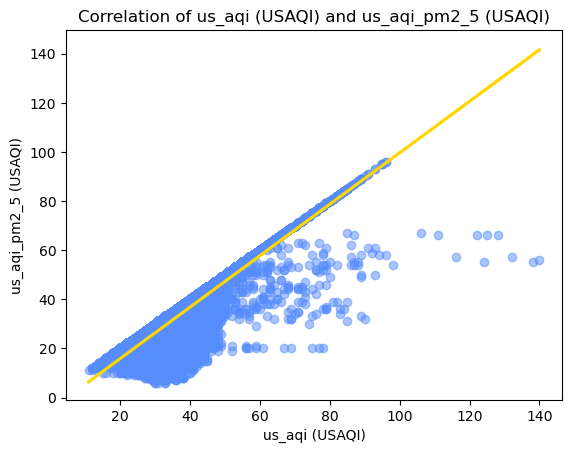

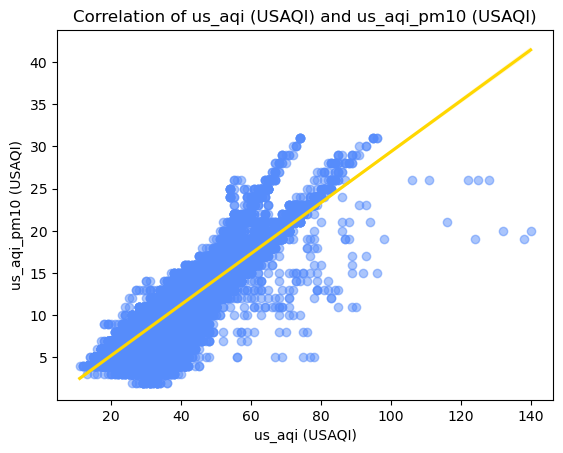

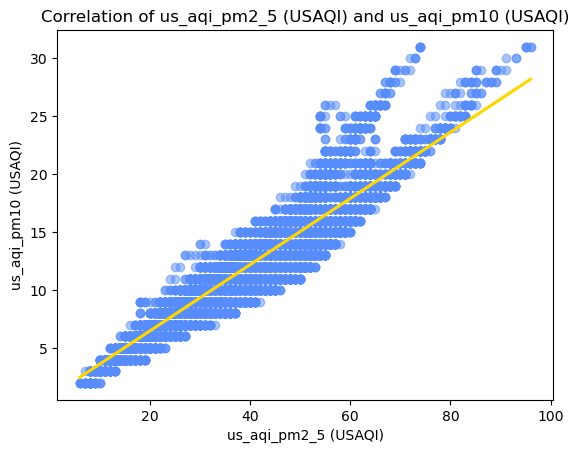

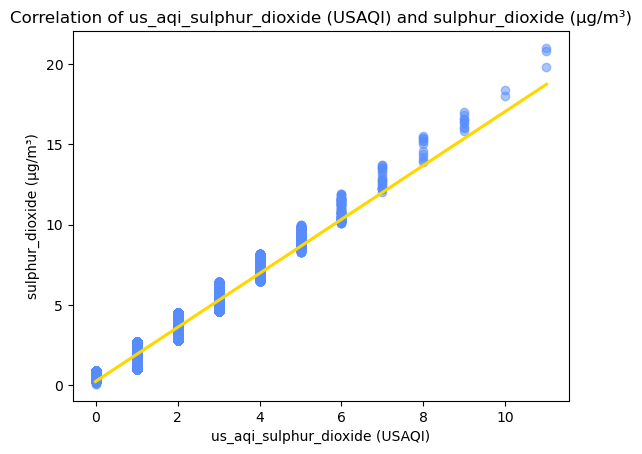

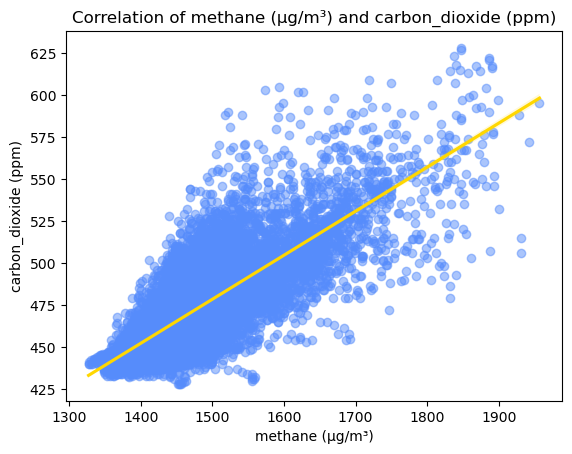

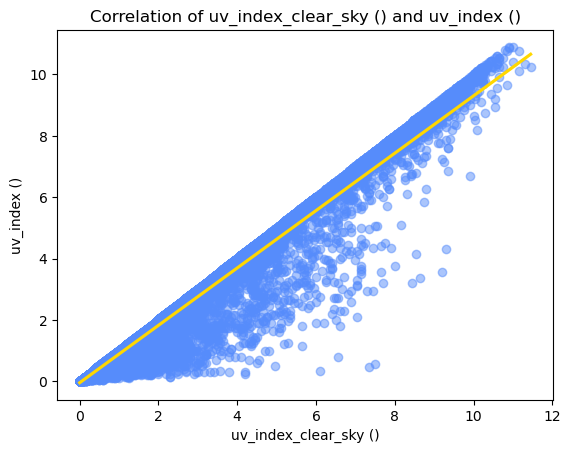

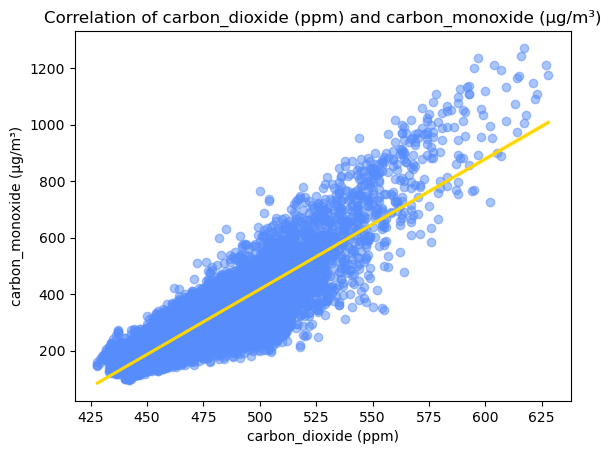

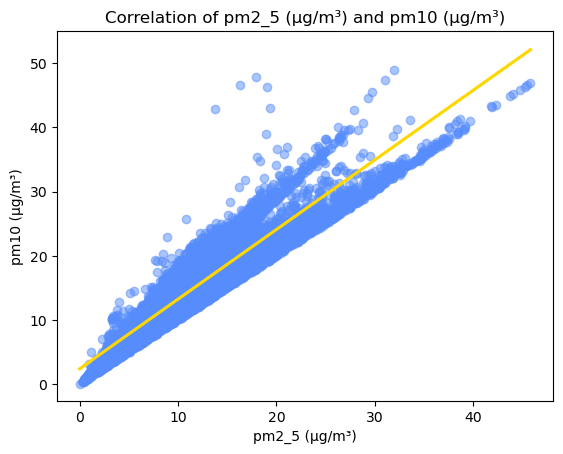

In [9]:
aq_scatterplots = [
    [aq_keys['us_aqi (USAQI)'], aq_keys['us_aqi_pm2_5 (USAQI)']],
    [aq_keys['us_aqi (USAQI)'], aq_keys['us_aqi_pm10 (USAQI)']],
    [aq_keys['us_aqi_pm2_5 (USAQI)'], aq_keys['us_aqi_pm10 (USAQI)']],
    [aq_keys['us_aqi_sulphur_dioxide (USAQI)'], aq_keys['sulphur_dioxide (μg/m³)']],
    [aq_keys['methane (μg/m³)'], aq_keys['carbon_dioxide (ppm)']],
    [aq_keys['uv_index_clear_sky ()'], aq_keys['uv_index ()']],
    [aq_keys['carbon_dioxide (ppm)'], aq_keys['carbon_monoxide (μg/m³)']],
    [aq_keys['pm2_5 (μg/m³)'], aq_keys['pm10 (μg/m³)']] 
]

for keys in aq_scatterplots:
    plt.figure()
    sb.regplot(
        data=aq,
        x=keys[0],
        y=keys[1],
        scatter_kws={ 'alpha': 0.5 },
        line_kws={ 'color':'gold' }
    )
    plt.title(f"Correlation of {keys[0]} and {keys[1]}")
    plt.show()

## Checkpoint

In [10]:
aq.to_csv(files['data/03-26-open-meteo-pre-narrowed.csv'], index=False)